In [1]:
# notebooks/ sits one level down, so point at the lesson modules and data.
# Written to be safe to re-run: it moves up only if it is not already there.
import sys, os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, os.getcwd())
%matplotlib inline
print('working directory:', os.getcwd())

working directory: /home/user/chiu__2022_rerun/tk_learning


# Lesson 6 — The same model in PyMC, and what Bayes buys you

Nothing about the kinetics changes. C(t) = (dose/Vd)*exp(-k*t) is still
the model. What changes is what we do with uncertainty:


```text
least squares   one best answer + a normal approximation to its
                uncertainty, valid near the optimum, conditional on
                the model being right

Bayes           a full distribution over parameters, which you can
                push through any function you like (half-life,
                clearance, a prediction in 2035) and get the right
                uncertainty for THAT quantity automatically
```

Three things you get that NLS cannot give you easily:
- priors, so the fit cannot run off to biologically absurd values
- hierarchy, so animals share strength without being forced equal
- exact uncertainty on derived quantities, no delta method

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm
import arviz as az

import plotting as P
from tk import load, half_life, iv_1comp

P.setup()

SEED = 20260929
mk = load("PFOA_Male_primate")
mk = mk[mk.conc_mgL > 0]
DOSE = 10.0

animals = np.sort(mk.animal_id.unique())
idx = np.searchsorted(animals, mk.animal_id.values)
t = mk.time_d.values
y = np.log(mk.conc_mgL.values)

print(f"Data: {len(mk)} observations, {len(animals)} monkeys, 10 mg/kg IV PFOA\n")

Data: 43 observations, 3 monkeys, 10 mg/kg IV PFOA



## A. Pooled model: one Vd and one k for all three animals

In [3]:
def pooled():
    with pm.Model() as m:
        # Priors on the LOG of each parameter -- guarantees positivity,
        # and a lognormal is the natural prior for a rate or a volume.
        #   ln Vd ~ N(ln 0.2, 0.5)  means: "most likely around 0.2 L/kg,
        #   and a factor of exp(2*0.5) = 2.7 either way is unremarkable"
        ln_Vd = pm.Normal("ln_Vd", np.log(0.2), 0.5)
        ln_k = pm.Normal("ln_k", np.log(0.06), 0.7)
        sigma = pm.HalfNormal("sigma", 0.5)      # residual SD on log scale

        mu = np.log(DOSE) - ln_Vd - pm.math.exp(ln_k) * t
        pm.Normal("obs", mu=mu, sigma=sigma, observed=y)

        # Deterministics are computed for every posterior draw, so their
        # uncertainty is exact -- no error propagation formula needed.
        pm.Deterministic("Vd", pm.math.exp(ln_Vd))
        pm.Deterministic("k", pm.math.exp(ln_k))
        pm.Deterministic("half_life", np.log(2) / pm.math.exp(ln_k))
        pm.Deterministic("CL", pm.math.exp(ln_k + ln_Vd))
    return m

## B. Hierarchical model: each animal gets its own k and Vd

In [4]:
def hierarchical():
    with pm.Model() as m:
        mu_ln_Vd = pm.Normal("mu_ln_Vd", np.log(0.2), 0.5)
        mu_ln_k = pm.Normal("mu_ln_k", np.log(0.06), 0.7)
        # Between-animal spread. HalfNormal(0.3) says "animals differ by
        # tens of percent, not orders of magnitude". Watch what happens:
        # the posterior for sd_ln_k comes back at about 0.48, well past
        # the prior's scale, because these three monkeys really do
        # differ by 3x. The data overruled the prior -- which is the
        # behaviour you want, and worth checking every time.
        sd_ln_Vd = pm.HalfNormal("sd_ln_Vd", 0.3)
        sd_ln_k = pm.HalfNormal("sd_ln_k", 0.3)

        # NON-CENTRED parameterisation: sample a standard normal z and
        # shift/scale it, rather than sampling the animal value directly.
        # Mathematically identical, far easier for the sampler when the
        # group-level SD is small. Chiu's model uses the same trick.
        z_Vd = pm.Normal("z_Vd", 0, 1, shape=len(animals))
        z_k = pm.Normal("z_k", 0, 1, shape=len(animals))
        ln_Vd_i = pm.Deterministic("ln_Vd_i", mu_ln_Vd + sd_ln_Vd * z_Vd)
        ln_k_i = pm.Deterministic("ln_k_i", mu_ln_k + sd_ln_k * z_k)

        sigma = pm.HalfNormal("sigma", 0.5)
        mu = np.log(DOSE) - ln_Vd_i[idx] - pm.math.exp(ln_k_i[idx]) * t
        pm.Normal("obs", mu=mu, sigma=sigma, observed=y)

        pm.Deterministic("half_life_pop", np.log(2) / pm.math.exp(mu_ln_k))
        pm.Deterministic("half_life_i", np.log(2) / pm.math.exp(ln_k_i))
    return m


def run(m, name):
    """Sample, and cache to disk so re-running is instant."""
    import os
    cache = f"trace_{name}.nc"
    if os.path.exists(cache):
        print(f"\n--- {name} (loaded from {cache}) ---")
        return az.from_netcdf(cache)
    with m:
        idata = pm.sample(1500, tune=1500, chains=4, random_seed=SEED,
                          target_accept=0.95, progressbar=False,
                          idata_kwargs={"log_likelihood": True})
    print(f"\n--- {name} ---")
    div = int(idata.sample_stats.diverging.sum())
    rhat = float(az.rhat(idata).to_array().max())
    print(f"divergences {div}   worst r-hat {rhat:.4f}"
          f"   {'OK' if div == 0 and rhat < 1.01 else 'CHECK THIS'}")
    idata.to_netcdf(cache)
    return idata

In [5]:
ip = run(pooled(), "pooled")
print(az.summary(ip, var_names=["Vd", "k", "half_life", "CL", "sigma"],
                 hdi_prob=0.95).to_string())


--- pooled (loaded from trace_pooled.nc) ---


             mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
Vd          0.180  0.026     0.130      0.231      0.000    0.000    3603.0    3475.0    1.0
k           0.061  0.004     0.052      0.069      0.000    0.000    4007.0    4026.0    1.0
half_life  11.460  0.845     9.891     13.185      0.014    0.012    4007.0    4026.0    1.0
CL          0.011  0.001     0.008      0.013      0.000    0.000    4749.0    4161.0    1.0
sigma       0.850  0.090     0.680      1.034      0.001    0.001    4049.0    3735.0    1.0


Read the table: 'mean' is the posterior mean, hdi_2.5%/97.5% the
credible interval -- the range containing 95% of the posterior
probability, which is what most people wrongly think a confidence
interval is. ess_bulk should be in the thousands, r_hat below 1.01.

Check it against least squares on the SAME data (all three animals,
`curve_fit` as in lesson 04): Vd 0.174 L/kg, half-life 11.29 days.
The posterior means are 0.180 and 11.46 -- agreement to a couple of
percent, which is what you should expect with weak priors and 43
observations. If they had disagreed, the prior would be doing work
you did not intend.

(Lesson 04's 8.59 days is not the comparison: that fit used monkey
2054 alone, and 2054 is the fastest of the three.)

In [6]:
ih = run(hierarchical(), "hierarchical")
print(az.summary(ih, var_names=["half_life_pop", "half_life_i",
                                "sd_ln_k", "sigma"],
                 hdi_prob=0.95).to_string())


--- hierarchical (loaded from trace_hierarchical.nc) ---
                  mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
half_life_pop   13.638  3.729     7.157     21.304      0.080    0.091    2210.0    2477.0    1.0
half_life_i[0]  27.123  5.838    17.919     38.809      0.074    0.132    6810.0    4897.0    1.0
half_life_i[1]   8.684  0.531     7.672      9.738      0.007    0.006    6115.0    4883.0    1.0
half_life_i[2]  10.574  0.522     9.633     11.674      0.007    0.006    6046.0    5267.0    1.0
sd_ln_k          0.478  0.140     0.234      0.753      0.002    0.002    3358.0    3494.0    1.0
sigma            0.478  0.056     0.375      0.589      0.001    0.001    4659.0    3655.0    1.0


Now each monkey has its own half-life, and the population value has
its own uncertainty on top. Look at sigma: it should have dropped
sharply from the pooled model, because variation that the pooled fit
had to call 'noise' is now explained by animals genuinely differing:
0.85 pooled against 0.48 hierarchical, on the log scale. Half the
apparent "measurement error" was in fact one monkey clearing PFOA
three times more slowly than the other two (27 days against 9).

That is PARTIAL POOLING. Each animal's estimate is pulled towards
the population mean by an amount that depends on how much data that
animal has -- automatically, with no tuning. It is the single most
useful idea in applied Bayesian modelling, and it is exactly what
Chiu's three-level human model (../chiu_replication/model.py) is doing at scale.

## C. Figures

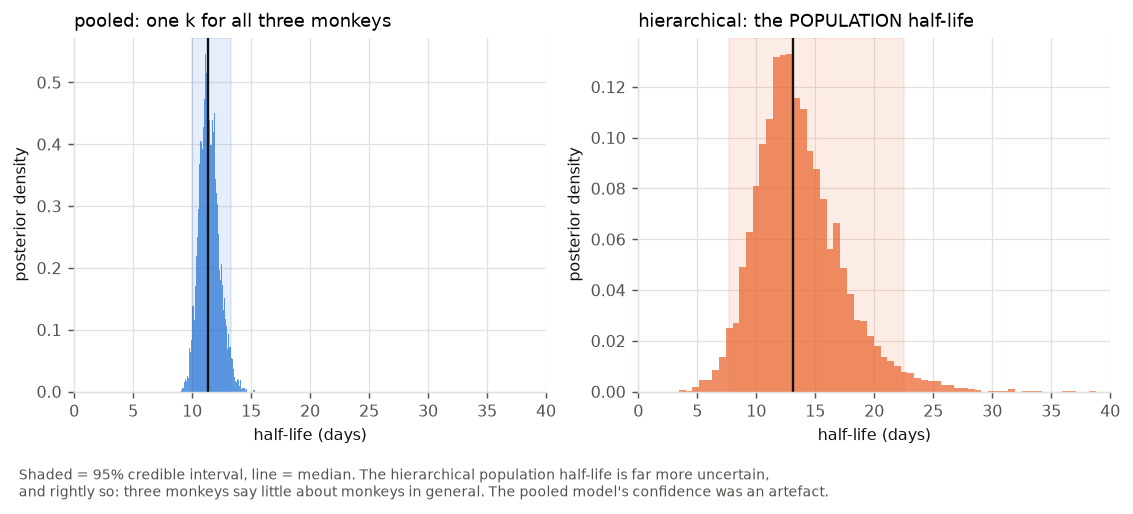

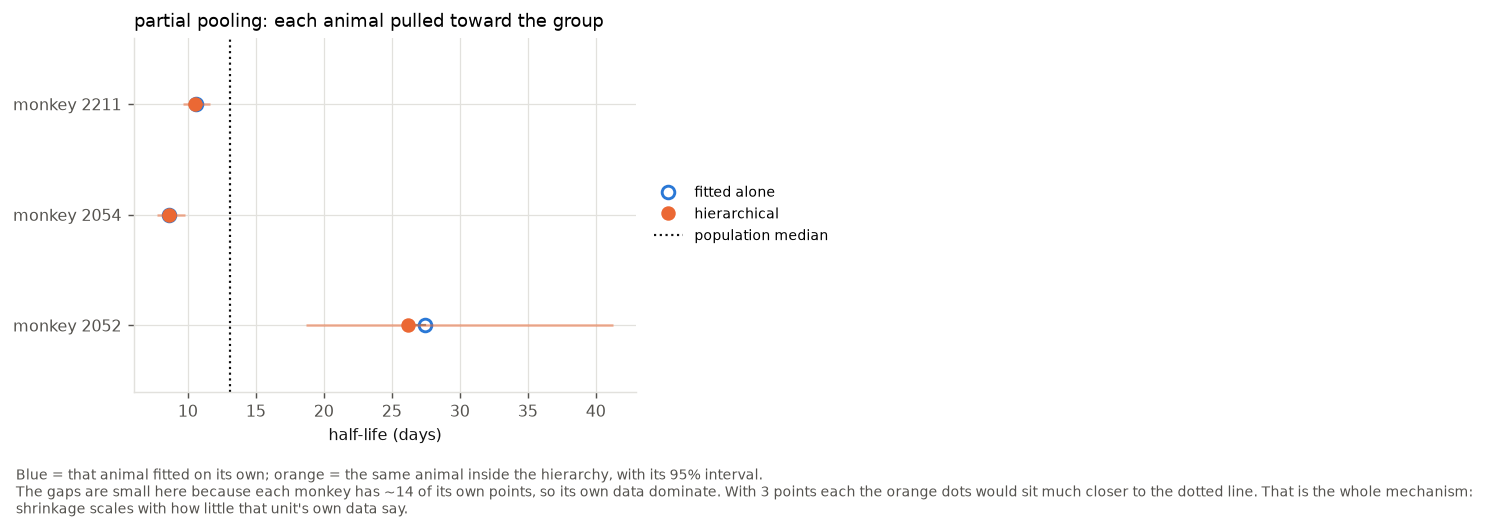

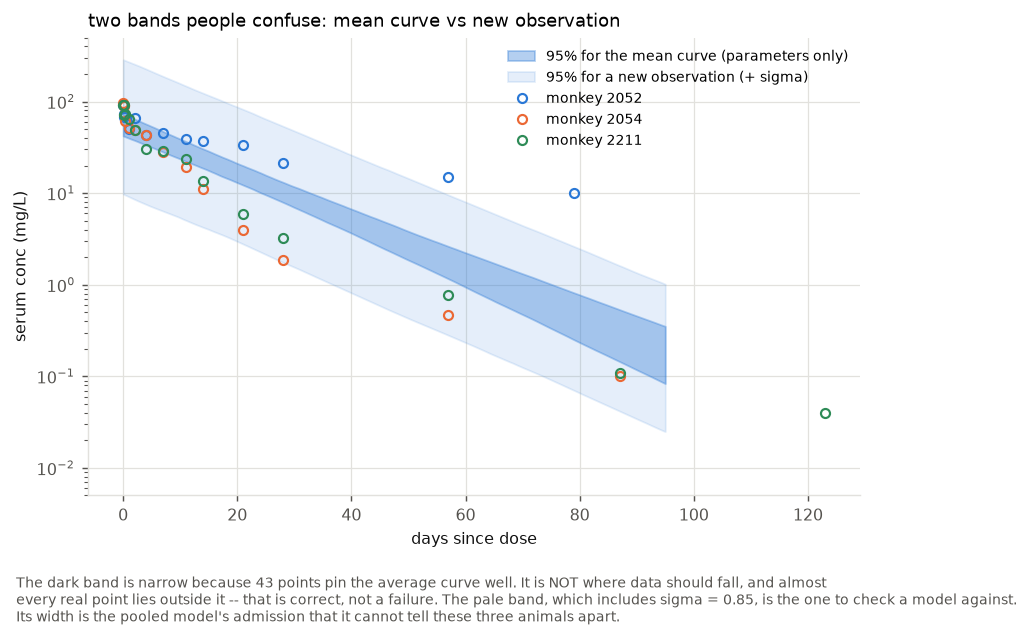

              rank   elpd_loo     p_loo  elpd_diff    weight        se        dse  warning scale
hierarchical     0 -34.878537  8.699071   0.000000  0.940542  6.176920   0.000000     True   log
pooled           1 -58.569507  6.033790  23.690971  0.059458  9.760171  10.335806     True   log


/tmp/claude-0/-home-user-chiu--2022-rerun/1d01819e-a495-5908-9e68-336af60a83fc/scratchpad/venv/lib/python3.11/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/tmp/claude-0/-home-user-chiu--2022-rerun/1d01819e-a495-5908-9e68-336af60a83fc/scratchpad/venv/lib/python3.11/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to hap

In [7]:
# C1 -- posterior densities. A Bayesian answer is a SHAPE, not a
# number with an error bar bolted on.
fig, (a, b) = plt.subplots(1, 2, figsize=(8.6, 3.4), constrained_layout=True)
hl_p = ip.posterior["half_life"].values.ravel()
hl_h = ih.posterior["half_life_pop"].values.ravel()
for ax, (vals, ttl, col) in zip(
        (a, b), [(hl_p, "pooled: one k for all three monkeys", P.BLUE),
                 (hl_h, "hierarchical: the POPULATION half-life", P.ORANGE)]):
    ax.hist(vals, bins=70, color=col, alpha=0.75, density=True)
    lo_, hi_ = np.percentile(vals, [2.5, 97.5])
    ax.axvline(np.median(vals), color=P.INK, lw=1.3)
    ax.axvspan(lo_, hi_, color=col, alpha=0.12)
    ax.set(xlabel="half-life (days)", ylabel="posterior density", xlim=(0, 40))
    ax.set_title(ttl)
P.save(fig, "06_posteriors.png",
       "Shaded = 95% credible interval, line = median. The "
       "hierarchical population half-life is far more uncertain,\n"
       "and rightly so: three monkeys say little about monkeys in "
       "general. The pooled model's confidence was an artefact.")

# C2 -- shrinkage. The single most useful picture in hierarchical
# modelling: each animal's own estimate, pulled toward the group.
fig, ax = plt.subplots(figsize=(6.4, 3.4), constrained_layout=True)
for j, aid in enumerate(animals):
    d = mk[mk.animal_id == aid]
    kk, C0 = np.polyfit(d.time_d, np.log(d.conc_mgL), 1)[:2]
    alone = np.log(2) / -kk                       # that animal, fitted alone
    post = ih.posterior["half_life_i"].values[:, :, j].ravel()
    ax.plot([alone, np.median(post)], [j, j], "-", color=P.GREY, lw=1.2)
    ax.plot(alone, j, "o", color=P.BLUE, ms=7, mfc="none", mew=1.6,
            label="fitted alone" if j == 0 else None)
    ax.plot(np.median(post), j, "o", color=P.ORANGE, ms=7,
            label="hierarchical" if j == 0 else None)
    ax.hlines(j, *np.percentile(post, [2.5, 97.5]), color=P.ORANGE, lw=1.4,
              alpha=0.5)
ax.axvline(np.median(hl_h), color=P.INK, ls=":", lw=1.2,
           label="population median")
ax.set_yticks(range(len(animals)), [f"monkey {a}" for a in animals])
ax.set(xlabel="half-life (days)", ylim=(-0.6, len(animals) - 0.4))
ax.set_title("partial pooling: each animal pulled toward the group")
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5))
P.save(fig, "06_shrinkage.png",
       "Blue = that animal fitted on its own; orange = the same "
       "animal inside the hierarchy, with its 95% interval.\n"
       "The gaps are small here because each monkey has ~14 of its "
       "own points, so its own data dominate. With 3 points each "
       "the orange dots would sit much closer to the dotted line. "
       "That is the whole mechanism:\nshrinkage scales with how "
       "little that unit's own data say.")

# C3 -- two DIFFERENT bands that beginners routinely conflate.
fig, ax = plt.subplots(figsize=(6.6, 4.2), constrained_layout=True)
grid = np.linspace(0.02, 95, 300)
Vd_p = ip.posterior["Vd"].values.ravel()
k_p = ip.posterior["k"].values.ravel()
sig_p = ip.posterior["sigma"].values.ravel()
curves = np.array([iv_1comp(grid, DOSE, v, kk)
                   for v, kk in zip(Vd_p[:1500], k_p[:1500])])

# (i) uncertainty in the MEAN curve: only the parameters vary.
lo_m, hi_m = np.percentile(curves, [2.5, 97.5], axis=0)
ax.fill_between(grid, lo_m, hi_m, color=P.BLUE, alpha=0.35,
                label="95% for the mean curve (parameters only)")

# (ii) where a NEW observation should fall: parameters AND sigma.
rng = np.random.default_rng(0)
pred = curves * np.exp(rng.normal(0, sig_p[:1500][:, None]))
lo_p, hi_p = np.percentile(pred, [2.5, 97.5], axis=0)
ax.fill_between(grid, lo_p, hi_p, color=P.BLUE, alpha=0.12,
                label="95% for a new observation (+ sigma)")

for aid, col in zip(animals, P.CYCLE):
    d = mk[mk.animal_id == aid]
    P.data_points(ax, d.time_d, d.conc_mgL, label=f"monkey {aid}", color=col)
ax.set(yscale="log", ylim=(0.005, 500), xlabel="days since dose",
       ylabel="serum conc (mg/L)")
ax.set_title("two bands people confuse: mean curve vs new observation")
ax.legend(loc="upper right", fontsize=7.5)
P.save(fig, "06_posterior_predictive.png",
       "The dark band is narrow because 43 points pin the average "
       "curve well. It is NOT where data should fall, and almost\n"
       "every real point lies outside it -- that is correct, not a "
       "failure. The pale band, which includes sigma = 0.85, is the "
       "one to check a model against.\nIts width is the pooled "
       "model's admission that it cannot tell these three animals "
       "apart.")

comp = az.compare({"pooled": ip, "hierarchical": ih}, ic="loo")
print(comp.to_string())

LOO (leave-one-out cross-validation) estimates out-of-sample
predictive accuracy. Higher elpd_loo is better; the ranking is what
matters, and elpd_diff should be compared to its own standard error
(dse) -- a difference smaller than about 2*dse is not decisive.

This is the same tool the EPA pipeline uses to choose between one and
two compartments, and the same one lesson 07 will use.

### Questions

1. In 06_posterior_predictive.png, which band would you use to answer "is this model adequate?", and which to answer "how well do we know the typical monkey's curve?" Getting these two confused is the most common error in reporting a Bayesian fit.
1. The pooled model's sigma mixes measurement error with between-animal differences. Which one does the hierarchical model move it into? Check the numbers.
1. Change the prior on ln_k to Normal(log(0.06), 0.05) -- very tight. Does the posterior move? What does that tell you about how much the data are actually saying?
1. sd_ln_k is estimated from three animals. Set its prior to HalfNormal(2.0) and rerun. What happens, and why is that a warning about hierarchical models on small groups?
1. Why is 'half_life' a Deterministic rather than something you compute afterwards from the posterior mean of k? (Hint: is ln2/mean(k) the same as mean(ln2/k)?)

### Exercises

1. Add a Deterministic for the predicted concentration at day 200 and report its credible interval. Notice how wide it is -- that is honest extrapolation uncertainty, and NLS will not hand it to you.
1. Fit the PFOS monkey data (PFOS_Male_primate, 2 mg/kg IV) the same way. PFOS should come out slower. By how much, and do the intervals overlap?
1. Run az.plot_trace and az.plot_pair on the pooled fit. The Vd-k correlation from lesson 04 section C should be visible directly.